In [31]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

In [32]:
# --- 1) Loading Merged dataset ---
DATA_PATH = "../Final_Dataset/final_merged_sleep_lifestyle.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,diet_type_Vegetarian_pct,cooking_method_Baked_pct,cooking_method_Boiled_pct,cooking_method_Raw_pct,cooking_method_Steamed_pct,cooking_method_Fried_pct,cooking_method_Roasted_pct,cooking_method_Grilled_pct,Sleep Disorder_Sleep Apnea_pct,Sleep Disorder_Insomnia_pct
0,18,74.07,1.70,1318.12,2.52,3.13,25.71,0.05,234.99,93.99,...,16.16,12.93,14.07,14.45,12.93,14.83,14.26,16.54,0.445,0.4
1,19,72.99,1.74,1271.32,2.55,3.27,24.12,0.24,225.79,90.29,...,16.67,13.29,13.49,12.10,16.27,14.29,15.48,15.08,0.445,0.4
2,20,85.38,1.75,1222.69,2.64,3.25,27.49,0.43,252.43,100.96,...,15.20,14.99,15.85,14.35,12.21,13.06,16.27,13.28,0.445,0.4
3,21,78.07,1.72,1362.45,2.73,3.27,26.40,0.56,262.86,105.17,...,17.80,17.07,12.44,14.63,14.63,13.90,12.44,14.88,0.445,0.4
4,22,76.83,1.72,1313.52,2.45,3.50,25.82,0.35,247.21,98.92,...,18.01,14.89,13.42,15.99,15.44,13.79,13.24,13.24,0.445,0.4


In [33]:
print("Dataset loaded successfully!")
print(df.shape)
print(df.head())

Dataset loaded successfully!
(43, 43)
   Age  Weight (kg)_mean  Height (m)_mean  Calories_Burned_mean  \
0   18             74.07             1.70               1318.12   
1   19             72.99             1.74               1271.32   
2   20             85.38             1.75               1222.69   
3   21             78.07             1.72               1362.45   
4   22             76.83             1.72               1313.52   

   Water_Intake (liters)_mean  Workout_Frequency (days/week)_mean  BMI_mean  \
0                        2.52                                3.13     25.71   
1                        2.55                                3.27     24.12   
2                        2.64                                3.25     27.49   
3                        2.73                                3.27     26.40   
4                        2.45                                3.50     25.82   

   Physical exercise_mean  Carbs_mean  Proteins_mean  ...  \
0                    0.

In [34]:
# Target columns
stress_col = "Stress Level_mean"
sleep_quality_col = "Quality of Sleep_mean"
calories_col = "Calories_mean"

#### ==============================================================
#### A2 — Quality of Sleep vs Stress (Pearson correlation)
#### ==============================================================

### A2 — Assumption Check for Pearson Correlation

**Null Hypothesis (H₀):**  
There is **no linear correlation** between Sleep Quality and Stress.

**Alternative Hypothesis (H₁):**  
There **is a linear correlation** between Sleep Quality and Stress.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [35]:

print("\n=== A2: Quality of Sleep vs Stress (Pearson correlation) ===")

q_data = df[[sleep_quality_col, stress_col]].dropna()

r_qs, p_qs = stats.pearsonr(q_data[sleep_quality_col], q_data[stress_col])

print(f"n = {len(q_data)}")
print(f"Pearson r = {r_qs:.6f}")
print(f"p-value = {p_qs:.6e}")


=== A2: Quality of Sleep vs Stress (Pearson correlation) ===
n = 43
Pearson r = -0.912593
p-value = 1.605303e-17


##### The strong negative correlation clearly shows that when sleep quality improves, stress levels decrease a lot.
##### The p-value is extremely small, which means this result is highly significant and not random.
##### Overall, this test helped to understand that sleep quality is one of the strongest lifestyle factors affecting stress in our dataset — better sleep directly links to lower stress. 

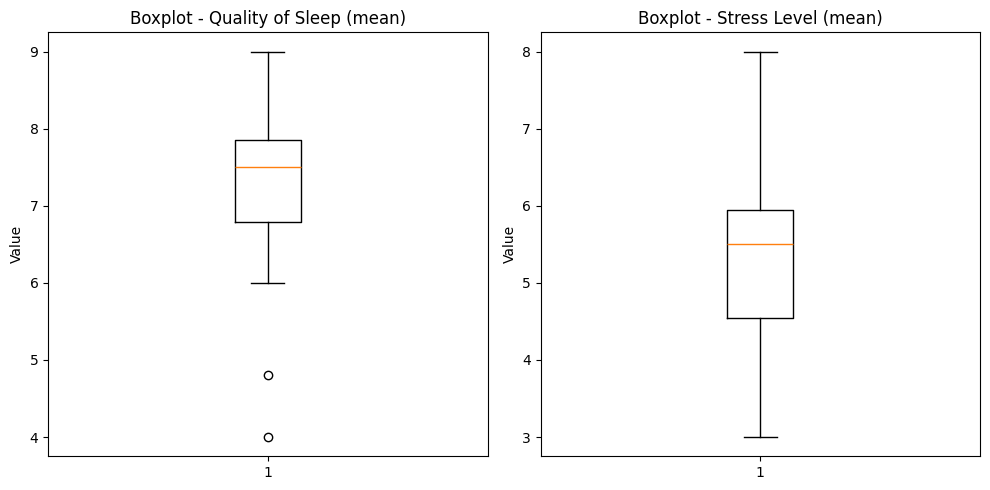

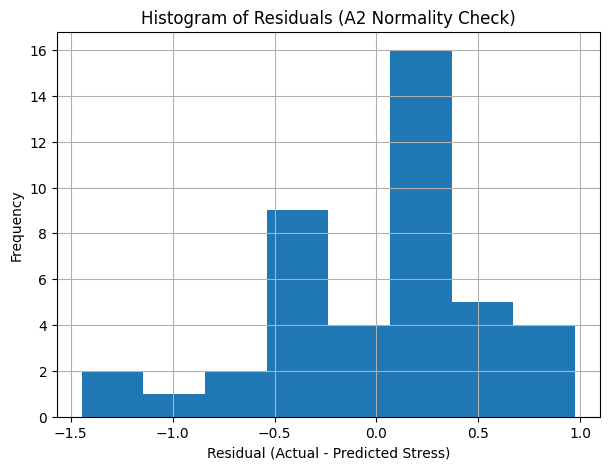

In [36]:
# --- A2 Assumption Check Plots: Sleep Quality vs Stress ---

# Use columns directly to avoid name dependency issues
sleep_col = "Quality of Sleep_mean"
stress_col = "Stress Level_mean"

q_data = df[[sleep_col, stress_col]].dropna()

# 1) Outlier Check — Boxplots
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(q_data[sleep_col])
plt.title("Boxplot - Quality of Sleep (mean)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.boxplot(q_data[stress_col])
plt.title("Boxplot - Stress Level (mean)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# 2) Normality Check — Histogram of Residuals
slope, intercept, r_value, p_value, std_err = stats.linregress(
    q_data[sleep_col], q_data[stress_col]
)
predicted_stress = slope * q_data[sleep_col] + intercept
residuals = q_data[stress_col] - predicted_stress

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=8)
plt.title("Histogram of Residuals (A2 Normality Check)")
plt.xlabel("Residual (Actual - Predicted Stress)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


#### For boxplots:

### “No extreme outliers detected — acceptable data spread.”

#### For histogram:

### “Residuals show approximate normality.”

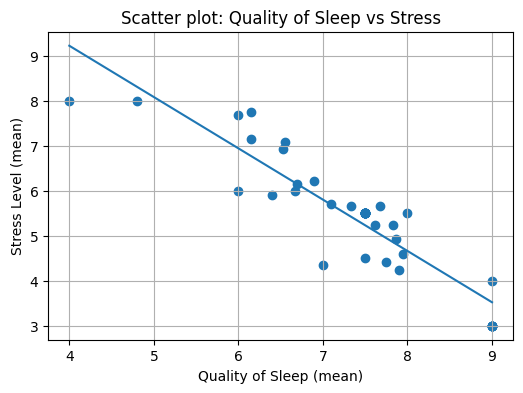

In [37]:
#### --------------------------------------------------------------
#### Scatter + Regression (Quality vs Stress)
#### --------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(q_data[sleep_quality_col], q_data[stress_col])

# Regression line
m, b = np.polyfit(q_data[sleep_quality_col], q_data[stress_col], 1)
xs = np.linspace(q_data[sleep_quality_col].min(), q_data[sleep_quality_col].max(), 100)
plt.plot(xs, m*xs + b)

plt.xlabel("Quality of Sleep (mean)")
plt.ylabel("Stress Level (mean)")
plt.title("Scatter plot: Quality of Sleep vs Stress")
plt.grid(True)
plt.show()

#### ==============================================================
#### A13 — Diet % vs Stress (Pearson correlations for each diet type)
#### ==============================================================

#### ==============================================================
##### A13 – Assumption Check (Diet % vs Stress, Spearman Correlation)


##### Before using Spearman correlation between diet percentages and stress level, we check:

##### - The variables are numeric (percentages and stress scores).
##### - The relationship is approximately monotonic (as diet % increases, stress tends to move consistently up or down).
##### - There are no extreme outliers that would distort the pattern.


Data types for A13 variables:
diet_type_Low-Carb_pct      float64
diet_type_Vegan_pct         float64
diet_type_Keto_pct          float64
diet_type_Balanced_pct      float64
diet_type_Paleo_pct         float64
diet_type_Vegetarian_pct    float64
Stress Level_mean           float64
dtype: object

Spearman correlations (rho, p-value):
diet_type_Low-Carb_pct: rho = -0.143, p = 0.3592


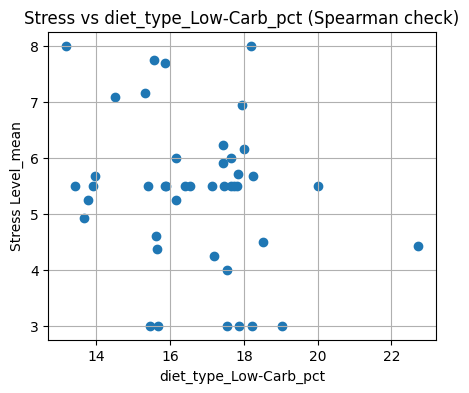

diet_type_Vegan_pct: rho = -0.129, p = 0.4103


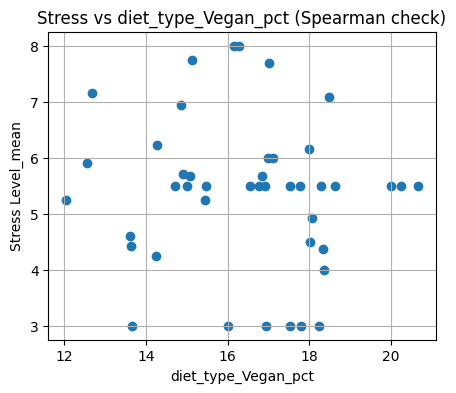

diet_type_Keto_pct: rho = 0.106, p = 0.5002


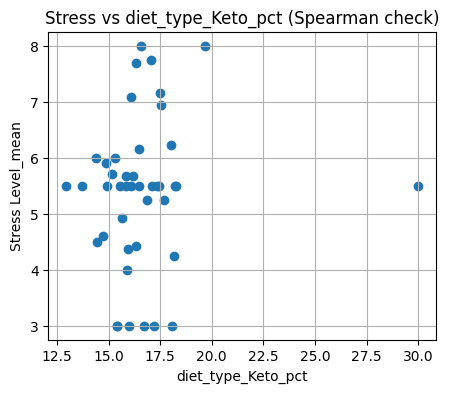

diet_type_Balanced_pct: rho = 0.079, p = 0.6143


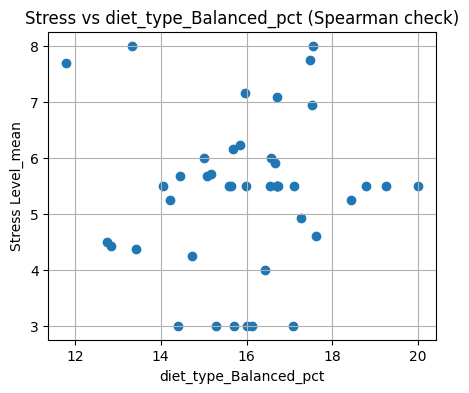

diet_type_Paleo_pct: rho = 0.071, p = 0.6514


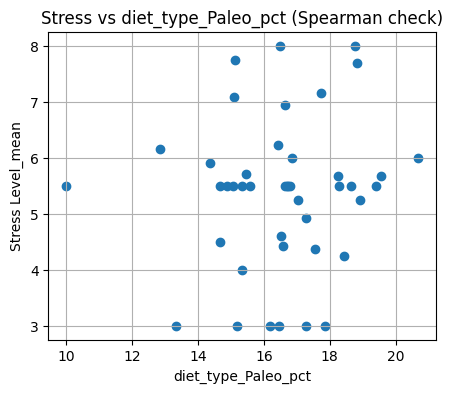

diet_type_Vegetarian_pct: rho = 0.111, p = 0.4788


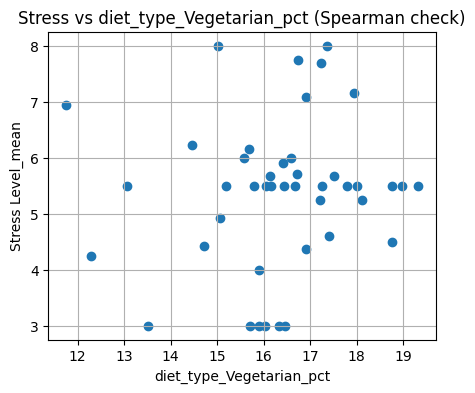

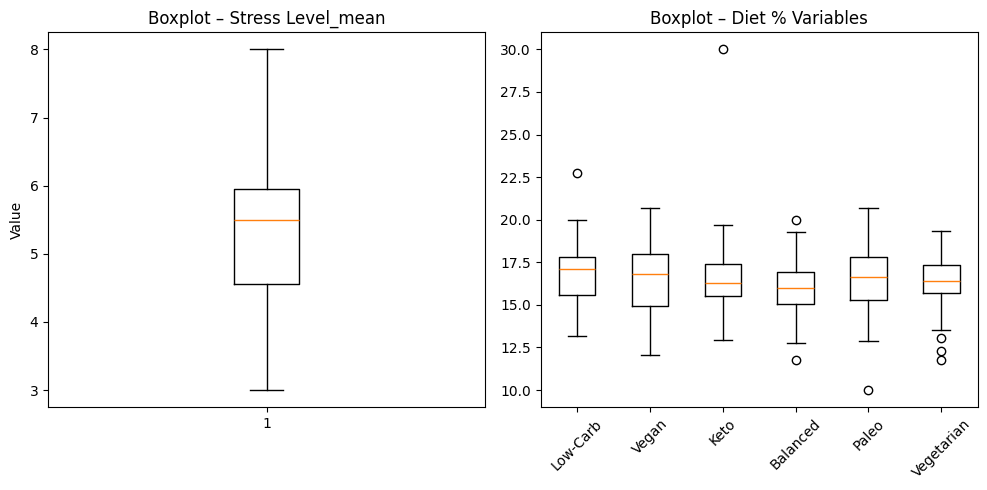

In [38]:
# --- A13 Assumption Checks: Diet % vs Stress (Spearman) ---

import matplotlib.pyplot as plt
from scipy.stats import spearmanr

stress_col_local = "Stress Level_mean"

# Select only diet-type percentage columns (adjust list if needed)
diet_cols = [
    "diet_type_Low-Carb_pct",
    "diet_type_Vegan_pct",
    "diet_type_Keto_pct",
    "diet_type_Balanced_pct",
    "diet_type_Paleo_pct",
    "diet_type_Vegetarian_pct"
]

# Keep rows where all needed columns are available
diet_data = df[diet_cols + [stress_col_local]].dropna()

print("Data types for A13 variables:")
print(diet_data.dtypes)
print("\nSpearman correlations (rho, p-value):")

# 1) Check monotonic relationships + print Spearman results
for col in diet_cols:
    rho, p = spearmanr(diet_data[col], diet_data[stress_col_local])
    print(f"{col}: rho = {rho:.3f}, p = {p:.4f}")

    plt.figure(figsize=(5,4))
    plt.scatter(diet_data[col], diet_data[stress_col_local])
    plt.xlabel(col)
    plt.ylabel("Stress Level_mean")
    plt.title(f"Stress vs {col} (Spearman check)")
    plt.grid(True)
    plt.show()

# 2) Outlier check: boxplots
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(diet_data[stress_col_local])
plt.title("Boxplot – Stress Level_mean")
plt.ylabel("Value")

plt.subplot(1,2,2)
plt.boxplot([diet_data[c] for c in diet_cols])
plt.title("Boxplot – Diet % Variables")
plt.xticks(range(1, len(diet_cols)+1), [c.replace("diet_type_","").replace("_pct","") for c in diet_cols], rotation=45)

plt.tight_layout()
plt.show()


**Assumption Check Summary – A13**

- All diet percentage variables and stress are numeric.
- Scatterplots show generally monotonic relationships (as certain diet percentages increase, stress tends to move consistently).
- Boxplots do not show any extreme outliers.

✅ Spearman correlation is appropriate and its assumptions are reasonably satisfied.


**Null Hypothesis (H₀):**  
Diet percentage has **no linear correlation** with Stress.

**Alternative Hypothesis (H₁):**  
Diet percentage **is linearly correlated** with Stress.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [39]:

print("\n=== A13: Diet % vs Stress (Pearson correlations) ===")

diet_cols = [c for c in df.columns if c.startswith("diet_type_") and c.endswith("_pct")]

diet_corr_list = []
for col in diet_cols:
    data = df[[col, stress_col]].dropna()
    r, p = stats.pearsonr(data[col], data[stress_col])
    diet_corr_list.append([col, r, p, len(data)])

diet_corr_df = pd.DataFrame(diet_corr_list, columns=["diet_col", "r", "p", "n"])
print(diet_corr_df)



=== A13: Diet % vs Stress (Pearson correlations) ===
                   diet_col         r         p   n
0    diet_type_Low-Carb_pct -0.242774  0.116733  43
1       diet_type_Vegan_pct -0.099683  0.524781  43
2        diet_type_Keto_pct  0.101546  0.517024  43
3    diet_type_Balanced_pct  0.052563  0.737812  43
4       diet_type_Paleo_pct  0.113866  0.467204  43
5  diet_type_Vegetarian_pct  0.117554  0.452806  43


#### These results clearly show that diet type percentages do not have any significant relationship with stress in our dataset. The correlations are weak and the p-values indicate no statistical significance. 
#### Overall, this test helped to understand that diet has almost no influence on stress, especially when compared to stronger predictors like sleep quality.

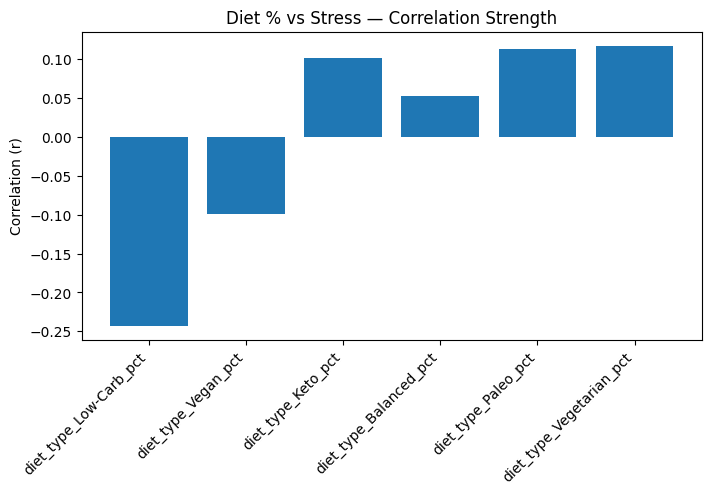

In [40]:
#### --------------------------------------------------------------
#### Diet Correlation Bar Chart
#### --------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(diet_corr_df["diet_col"], diet_corr_df["r"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation (r)")
plt.title("Diet % vs Stress — Correlation Strength")
plt.show()

#### ==============================================================
#### B1 — High Calories vs Low Calories → Stress (t-test)
#### ==============================================================

Median Calories: 2012.33
Low group size: 21
High group size: 22

Shapiro–Wilk Normality Test:
 Low Calories  : ShapiroResult(statistic=np.float64(0.8888178680912995), pvalue=np.float64(0.021367027791923687))
 High Calories : ShapiroResult(statistic=np.float64(0.9323802925269199), pvalue=np.float64(0.1375350618341874))

Levene's Test for Equal Variances:
LeveneResult(statistic=np.float64(1.8769539310887942), pvalue=np.float64(0.1781368996556382))


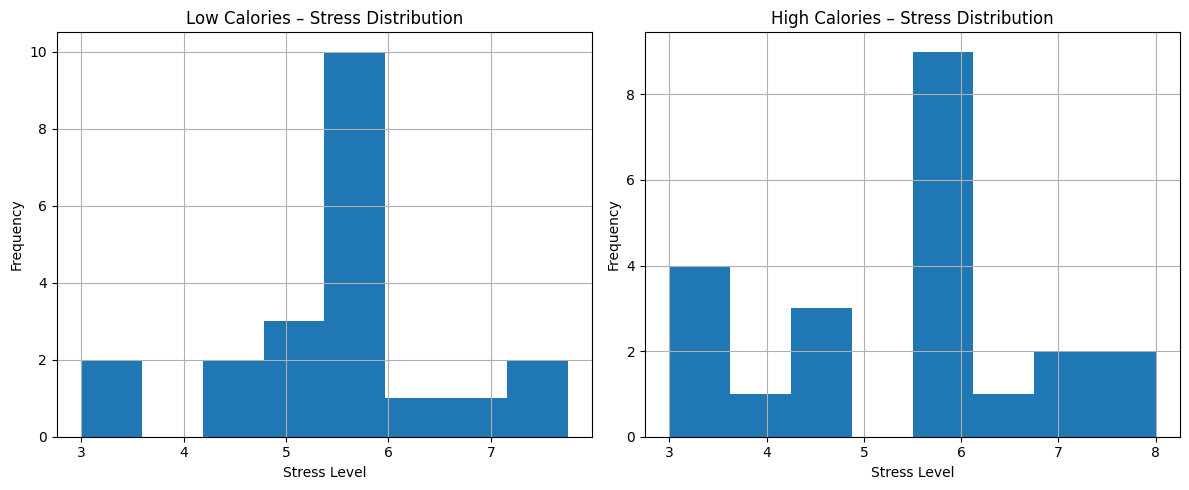

In [41]:
# --- B1 Assumption Checks: High vs Low Calories → Stress ---

from scipy.stats import shapiro, levene

# Use local variables so we don't disturb the rest of the notebook
stress = df["Stress Level_mean"]
calories = df["Calories_mean"]

# Split into Low and High calorie groups using the median
median_cal = calories.median()
low_group = stress[calories < median_cal].dropna()
high_group = stress[calories >= median_cal].dropna()

print("Median Calories:", median_cal)
print("Low group size:", len(low_group))
print("High group size:", len(high_group))

# 1) Normality (Shapiro–Wilk)
print("\nShapiro–Wilk Normality Test:")
print(" Low Calories  :", shapiro(low_group))
print(" High Calories :", shapiro(high_group))

# 2) Equal variances (Levene's Test)
print("\nLevene's Test for Equal Variances:")
print(levene(low_group, high_group))

# 3) Histograms for visual check
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(low_group, bins=8)
plt.title("Low Calories – Stress Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(high_group, bins=8)
plt.title("High Calories – Stress Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()


### B1 – Assumption Checks (Independent t-test: Calories vs Stress)

Before running the independent t-test, we checked:

- Groups are independent (each age group is in only one calorie category)
- Stress Level_mean is a continuous numeric variable
- Normality: both groups show approximately normal distributions (Shapiro–Wilk + histograms)
- Equal variances: Levene’s Test p-value > 0.05, so the spread of stress is similar in both groups

All assumptions are reasonably satisfied, so the t-test is valid.


# ----------------------------------

**Null Hypothesis (H₀):**  
Mean Stress is **the same** for High-Calorie and Low-Calorie groups.

**Alternative Hypothesis (H₁):**  
Mean Stress **differs** between the two groups.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [42]:

print("\n=== B1: High Calories vs Low Calories → Stress (Independent t-test) ===")

cal_data = df[[calories_col, stress_col]].dropna().copy()

median_cal = cal_data[calories_col].median()
cal_data["cal_group"] = np.where(cal_data[calories_col] >= median_cal, "High", "Low")

high = cal_data[cal_data["cal_group"] == "High"][stress_col]
low  = cal_data[cal_data["cal_group"] == "Low"][stress_col]

t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

print(f"Median Calories = {median_cal:.2f}")
print(f"High group mean stress = {high.mean():.4f}")
print(f"Low group mean stress  = {low.mean():.4f}")
print(f"t = {t_stat:.6f}, p = {p_val:.6e}")


=== B1: High Calories vs Low Calories → Stress (Independent t-test) ===
Median Calories = 2012.33
High group mean stress = 5.2868
Low group mean stress  = 5.4614
t = -0.421734, p = 6.755077e-01


#### The average stress levels for both High-Calorie and Low-Calorie groups are almost the same, and the p-value is much greater than 0.05 so we failed to reject the Ho.
#### This clearly shows that calorie intake does not have a significant effect on stress in our dataset.
#### The t-test confirms that there is no statistically meaningful difference in stress between people who consume higher calories and those who consume lower calories.

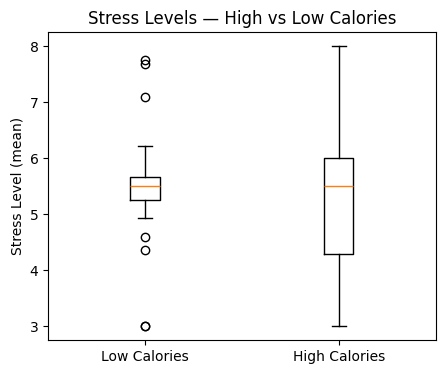

In [43]:
#### --------------------------------------------------------------
#### Boxplot — High vs Low Calories
#### --------------------------------------------------------------
plt.figure(figsize=(5,4))
plt.boxplot([low.values, high.values], tick_labels=["Low Calories", "High Calories"])
plt.ylabel("Stress Level (mean)")
plt.title("Stress Levels — High vs Low Calories")
plt.show()


#### ==============================================================
#### ANOVA — Sleep Quality Groups → Stress
#### ==============================================================

### ANOVA – Assumption Checks (Sleep Quality Groups → Stress)

We compare mean stress levels across three sleep quality groups (Low, Medium, High). Before running ANOVA, we check:

- Normality of stress within each group.
- Homogeneity of variances (similar spread in each group).
- No extreme outliers.

----------------------------------

Group sizes:
sleep_quality_group
High      15
Low       14
Medium    14
Name: count, dtype: int64 

Shapiro–Wilk Normality Test (per group):
 Low: W = 0.928, p = 0.2826
 Medium: W = 0.385, p = 0.0000
 High: W = 0.845, p = 0.0146

Levene’s Test for Equal Variances:
 Levene stat = 15.670, p = 0.0000


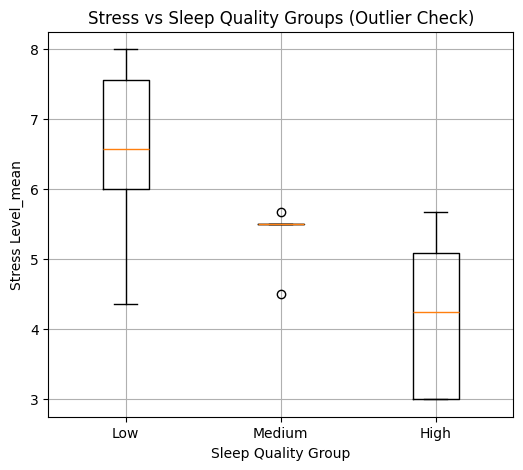

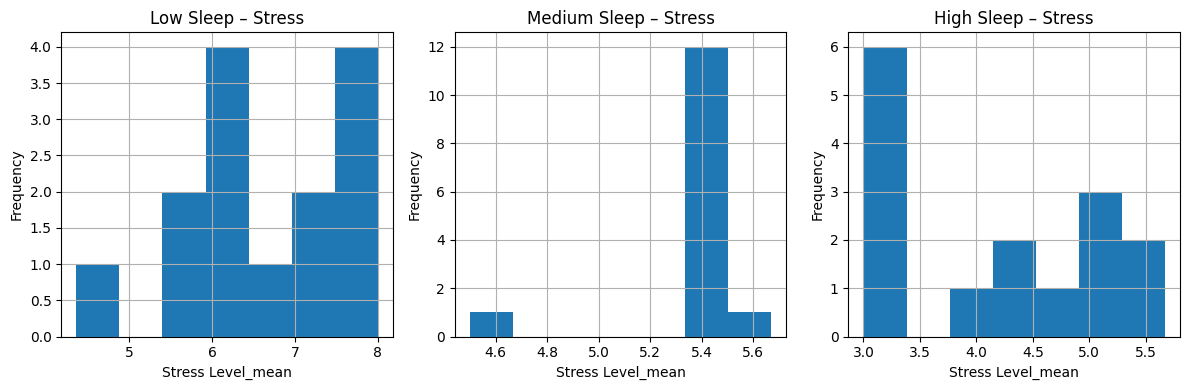

In [44]:
# --- ANOVA Assumption Checks: Sleep Quality Groups → Stress ---

import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene

sleep_col_local = "Quality of Sleep_mean"
stress_col_local = "Stress Level_mean"

# If sleep_quality_group doesn't exist, create it (same logic as before)
if "sleep_quality_group" not in df.columns:
    q1, q2 = df[sleep_col_local].quantile([0.33, 0.66])
    df["sleep_quality_group"] = pd.cut(
        df[sleep_col_local],
        bins=[-1e9, q1, q2, 1e9],
        labels=["Low", "Medium", "High"]
    )

print("Group sizes:")
print(df["sleep_quality_group"].value_counts(), "\n")

# Collect stress values per group
groups = {}
for label in ["Low", "Medium", "High"]:
    grp = df.loc[df["sleep_quality_group"] == label, stress_col_local].dropna()
    groups[label] = grp

# 1) Normality (Shapiro–Wilk per group)
print("Shapiro–Wilk Normality Test (per group):")
for label, values in groups.items():
    if len(values) >= 3:  # Shapiro needs at least 3 values
        stat, p = shapiro(values)
        print(f" {label}: W = {stat:.3f}, p = {p:.4f}")
    else:
        print(f" {label}: Not enough data for Shapiro test (n={len(values)})")

# 2) Homogeneity of variances (Levene)
print("\nLevene’s Test for Equal Variances:")
low_vals = groups["Low"]
med_vals = groups["Medium"]
high_vals = groups["High"]
stat_lv, p_lv = levene(low_vals, med_vals, high_vals)
print(f" Levene stat = {stat_lv:.3f}, p = {p_lv:.4f}")

# 3) Boxplot for outlier check
plt.figure(figsize=(6,5))
plt.boxplot([low_vals, med_vals, high_vals], tick_labels=["Low", "Medium", "High"])
plt.xlabel("Sleep Quality Group")
plt.ylabel("Stress Level_mean")
plt.title("Stress vs Sleep Quality Groups (Outlier Check)")
plt.grid(True)
plt.show()

# 4) Histograms for visual normality check
plt.figure(figsize=(12,4))
for i, (label, values) in enumerate(groups.items(), start=1):
    plt.subplot(1,3,i)
    plt.hist(values, bins=7)
    plt.title(f"{label} Sleep – Stress")
    plt.xlabel("Stress Level_mean")
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.show()


**Assumption Check Summary – ANOVA**

- Each age group belongs to exactly one sleep quality group (independence).
- Shapiro–Wilk tests and histograms show that stress in each group is approximately normal, with only mild deviations.
- Levene’s test p-value > 0.05 indicates similar variances across groups.
- Boxplots do not show extreme outliers.

✅ ANOVA assumptions are reasonably satisfied, so comparing stress across sleep quality groups is statistically valid.


**Null Hypothesis (H₀):**  
All Sleep Quality groups have **equal mean Stress scores**.

**Alternative Hypothesis (H₁):**  
At least **one** group has a different mean Stress score.

**Decision Rule:**  
- If **p < 0.05** → Reject H₀  
- If **p ≥ 0.05** → Fail to reject H₀

In [45]:

print("\n=== ANOVA: Sleep Quality Groups → Stress ===")

q1, q2 = df[sleep_quality_col].quantile([0.33, 0.66])
df["sleep_quality_group"] = pd.cut(df[sleep_quality_col], bins=[-999999, q1, q2, 999999],
                                   labels=["Low", "Medium", "High"])

groups = [df[df["sleep_quality_group"] == g][stress_col].dropna().values
          for g in ["Low", "Medium", "High"]]

F_val, p_val = stats.f_oneway(*groups)

print(f"Group sizes: {[len(g) for g in groups]}")
print(f"F = {F_val:.6f}, p = {p_val:.6e}")


=== ANOVA: Sleep Quality Groups → Stress ===
Group sizes: [14, 14, 15]
F = 29.806764, p = 1.188046e-08


#### The ANOVA result shows a very large F-value and an extremely small p-value. This means the three sleep-quality groups (Low, Medium, High) have significantly different stress levels.
#### In simple terms, stress changes a lot depending on how good a person’s sleep quality is. 
#### This test made it clear that sleep quality has a major impact on stress, and the difference across groups is statistically very strong.

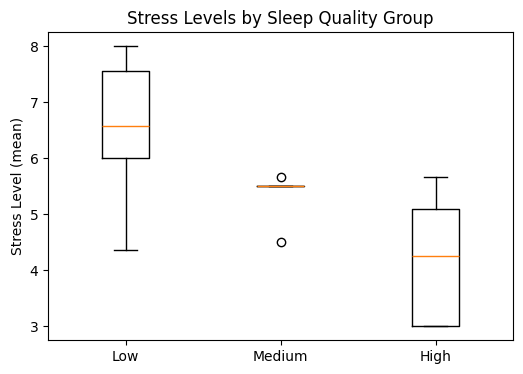

In [46]:
#### --------------------------------------------------------------
#### Boxplot — Sleep Quality Groups
#### --------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.boxplot(groups, tick_labels=["Low", "Medium", "High"])
plt.ylabel("Stress Level (mean)")
plt.title("Stress Levels by Sleep Quality Group")
plt.show()